# Group Pipeline: Weather-Based Activity Suitability — Preprocessing & EDA
**Group ID:** Y2-S1-MLB-B1G1-10 · **Dataset:** `weatherHistory.csv` (96,453 hourly records)

This notebook integrates all six members' individual preprocessing steps into one end-to-end pipeline, in the order they need to run: missing data → duplicates/dates → categorical encoding → outlier treatment → feature engineering/selection → scaling & PCA. The final output is the cleaned, encoded, scaled dataset ready for the modelling stage of the assignment.

| Step | Technique | Member | IT Number |
|---|---|---|---|
| 1 | Missing Data Handling | Dulaj G. A. M | IT25102052 |
| 2 | Duplicate Detection & Removal | Sooriyaarachchi S.A.V.S. | IT25103007 |
| 3 | Categorical Encoding | Humaid H M | IT25300054 |
| 4 | Outlier Detection & Treatment | Perera K.T. B | IT25102202 |
| 5 | Feature Engineering & Selection | Weerathunga T. L | IT25300254 |
| 6 | Scaling & PCA | Perera G.T. D | IT25101195 |

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/raw/weatherHistory.csv")
print("Raw shape:", df.shape)

Raw shape: (96453, 12)


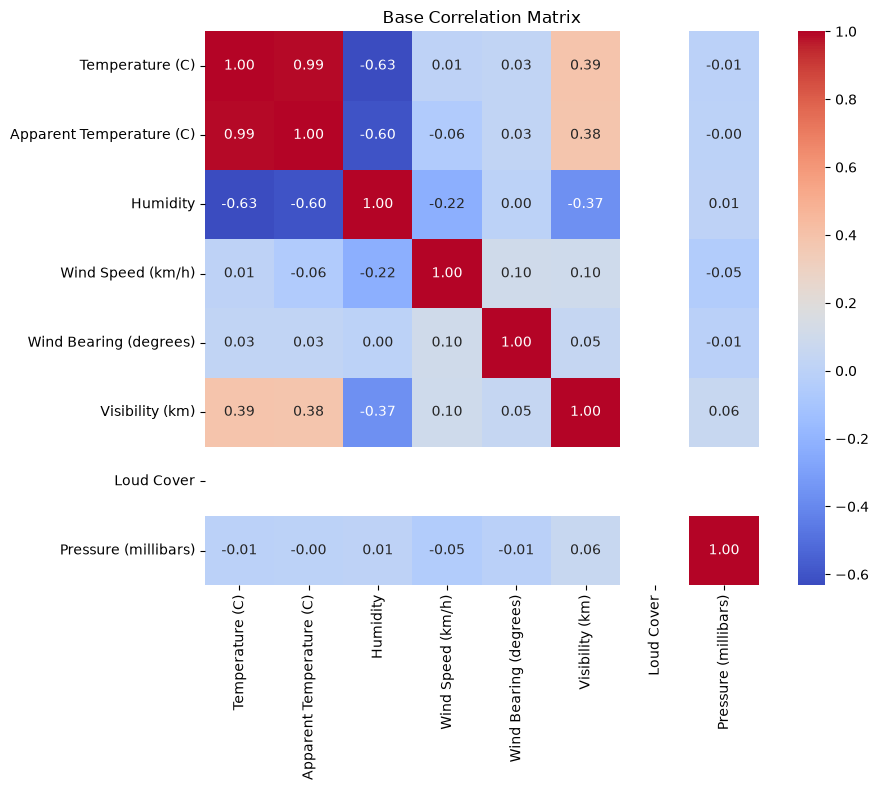

In [13]:
# Select numeric columns
num_cols = df.select_dtypes(include="number").columns

# Create correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Base Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
df["Loud Cover"].value_counts()

Loud Cover
0.0    96429
Name: count, dtype: int64

## Step 1 — Missing Data Handling (IT25102052)

In [14]:
print("Missing before:\n", df.isnull().sum()[df.isnull().sum() > 0])
df["Precip Type"] = df["Precip Type"].fillna("none")
print("\nMissing after:", df.isnull().sum().sum())

Missing before:
 Precip Type    517
dtype: int64

Missing after: 0


## Step 2 — Duplicate Detection & Removal + Date Parsing (IT25103007)

In [15]:
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)
print("Shape after dedup:", df.shape)

Duplicates found: 24
Shape after dedup: (96429, 12)


## Step 3 — Categorical Encoding (IT25300054)

In [16]:
def simplify_weather(summary):
    summary = summary.lower()
    if "rain" in summary or "drizzle" in summary:
        return "Rainy"
    elif "foggy" in summary:
        return "Foggy"
    elif "cloudy" in summary or "overcast" in summary:
        return "Cloudy"
    elif "clear" in summary:
        return "Clear"
    elif "windy" in summary or "breezy" in summary:
        return "Windy"
    else:
        return "Other"

df["Daily_Summary_Simplified"] = df["Daily Summary"].apply(simplify_weather)
df = pd.get_dummies(df, columns=["Precip Type"], prefix="Precip")
df["Summary_encoded"] = LabelEncoder().fit_transform(df["Summary"])
print("Daily_Summary_Simplified categories:", df["Daily_Summary_Simplified"].nunique())
print(df.filter(like="Precip_").sum())

Daily_Summary_Simplified categories: 5
Precip_none      517
Precip_rain    85200
Precip_snow    10712
dtype: int64


## Step 4 — Outlier Detection & Treatment (IT25102202)

In [17]:
# Pressure = 0 -> sensor fault -> fill with median of valid readings
valid_pressure_median = df.loc[df["Pressure (millibars)"] > 0, "Pressure (millibars)"].median()
df["Pressure (millibars)"] = df["Pressure (millibars)"].replace(0, valid_pressure_median)

# Winsorize genuine statistical outliers instead of dropping rows
for col in ["Temperature (C)", "Apparent Temperature (C)", "Humidity", "Wind Speed (km/h)"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

print("Pressure = 0 remaining:", (df["Pressure (millibars)"] == 0).sum())
print("Rows remaining:", len(df))

Pressure = 0 remaining: 0
Rows remaining: 96429


## Step 5 — Feature Engineering & Target/Feature Selection (IT25300254)

In [18]:
df["year"] = df["Formatted Date"].dt.year
df["month"] = df["Formatted Date"].dt.month
df["day"] = df["Formatted Date"].dt.day
df["hour"] = df["Formatted Date"].dt.hour
df["day_of_week"] = df["Formatted Date"].dt.dayofweek

suit_conditions = (
    (df["Wind Speed (km/h)"] < 20) &
    (df["Humidity"] < 0.80) &
    (df["Temperature (C)"] > 18) &
    (df["Apparent Temperature (C)"] < 32) &
    (df["Precip_none"] == True)
)

df["suitability"] = np.where(suit_conditions, "Suitable", "Not Suitable")
print(df["suitability"].value_counts())

# Domain-justified feature set (see Member 5's notebook for why MI ranking was not used directly:
# with only 23/96,453 positive cases, mutual_info_classif is unreliable at this class imbalance)
selected_features = ["Temperature (C)", "Apparent Temperature (C)", "Humidity", "Wind Speed (km/h)"]
print("\nSelected numeric features:", selected_features)

suitability
Not Suitable    96406
Suitable           23
Name: count, dtype: int64

Selected numeric features: ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)']


## Step 6 — Scaling & PCA (IT25101195)

In [19]:
num_cols = ["Temperature (C)", "Apparent Temperature (C)", "Humidity",
            "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]

scaler = StandardScaler()
scaled = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled, columns=[f"{c}_scaled" for c in num_cols])

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(scaled)
scaled_df["PC1"] = pcs[:, 0]
scaled_df["PC2"] = pcs[:, 1]
print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_.round(3))

Explained variance (PC1, PC2): [0.409 0.177]


## Final integrated output

In [20]:
final_df = pd.concat([
    df[["Formatted Date", "year", "month", "day", "hour", "day_of_week",
        "Summary", "Summary_encoded", "Daily_Summary_Simplified"] +
       [c for c in df.columns if c.startswith("Precip_")] +
       num_cols + ["suitability"]].reset_index(drop=True),
    scaled_df.reset_index(drop=True)
], axis=1)

print("Final integrated shape:", final_df.shape)
final_df.head()

Final integrated shape: (96429, 29)


,Formatted Date,year,month,day,hour,day_of_week,Summary,Summary_encoded,Daily_Summary_Simplified,Precip_none,...,suitability,Temperature (C)_scaled,Apparent Temperature (C)_scaled,Humidity_scaled,Wind Speed (km/h)_scaled,Wind Bearing (degrees)_scaled,Visibility (km)_scaled,Pressure (millibars)_scaled,PC1,PC2
0,2006-03-31 22:00:00+00:00,2006,3,31,22,4,Partly Cloudy,19,Cloudy,False,...,Not Suitable,-0.257497,-0.323832,0.793828,0.537176,0.591404,1.306867,-0.217538,-0.099765,0.980633
1,2006-03-31 23:00:00+00:00,2006,3,31,23,4,Partly Cloudy,19,Cloudy,False,...,Not Suitable,-0.269716,-0.338897,0.640240,0.559665,0.665908,1.306867,-0.152831,-0.055039,0.993276
2,2006-04-01 00:00:00+00:00,2006,4,1,0,5,Mostly Cloudy,17,Cloudy,False,...,Not Suitable,-0.267389,-0.137858,0.793828,-1.044564,0.153689,1.099498,-0.112713,-0.273705,-0.431172
3,2006-04-01 01:00:00+00:00,2006,4,1,1,5,Partly Cloudy,19,Cloudy,False,...,Not Suitable,-0.381440,-0.458897,0.486652,0.534677,0.759039,1.306867,-0.051889,-0.135548,0.999337
4,2006-04-01 02:00:00+00:00,2006,4,1,2,5,Mostly Cloudy,17,Cloudy,False,...,Not Suitable,-0.332561,-0.362273,0.486652,0.059905,0.665908,1.306867,-0.038947,-0.109102,0.588920


In [21]:
import os
os.makedirs("../results/outputs", exist_ok=True)
final_df.to_csv("../results/outputs/weatherHistory_cleaned_final.csv", index=False)
print("Saved final pipeline output to results/outputs/weatherHistory_cleaned_final.csv")
print("Rows:", len(final_df), "| Columns:", len(final_df.columns))

Saved final pipeline output to results/outputs/weatherHistory_cleaned_final.csv
Rows: 96429 | Columns: 29


## Sanity-check visualization: correlation of final numeric features

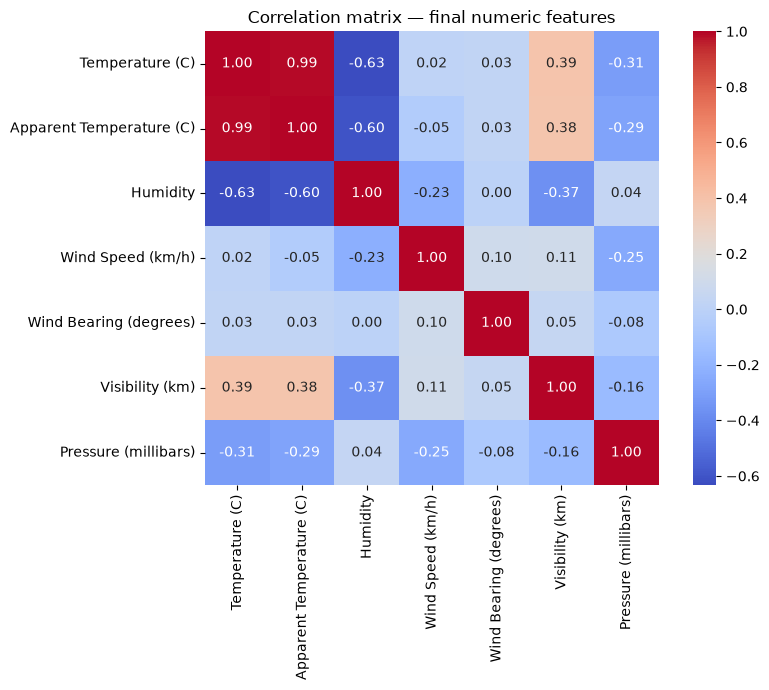

In [22]:
plt.figure(figsize=(9, 7))
corr = final_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation matrix — final numeric features")
plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/group_pipeline_correlation.png", dpi=110)
plt.show()

**Interpretation:** Temperature and Apparent Temperature are (as expected) very strongly correlated (they measure almost the same thing), which is useful context for anyone modelling downstream — using both as independent features would be largely redundant. Humidity shows a moderate negative correlation with Temperature, and Pressure/Visibility/Wind Bearing are only weakly related to the other features, meaning they contribute distinct information rather than duplicating what Temperature and Humidity already capture.